In [1]:
import numpy as np
import scipy.stats as stats
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from dynamic_routing_analysis import decoding_utils
# import dynamic_routing_analysis as dra
# import npc_lims

import matplotlib
import matplotlib.font_manager as fm

matplotlib.rcParams['font.size'] = 8
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
fm.FontProperties().set_family('arial')

%load_ext autoreload
%autoreload 2
# %matplotlib inline
%matplotlib widget

In [2]:
session_table_path=r"\\allen\programs\mindscope\workgroups\dynamicrouting\Ethan\CO decoding results\session_table_v0.272.parquet"
session_table=pl.read_parquet(session_table_path)

dr_session_list=(
    session_table.filter(
    pl.col('project')=="DynamicRouting",
    pl.col('is_production'),
    pl.col('is_annotated'),
    pl.col('issues')==[],
    pl.col('is_good_behavior').eq(True),
    )['session_id'].to_list()
    )

templeton_session_list=(
    session_table.filter(
    pl.col('project')=="Templeton",
    pl.col('is_production'),
    pl.col('is_annotated'),
    pl.col('issues')==[],
    # pl.col('is_good_behavior').eq(True),
    )['session_id'].to_list()
    )
templeton_session_list

['620263_2022-07-26',
 '620263_2022-07-27',
 '620264_2022-08-02',
 '628801_2022-09-19',
 '636397_2022-09-26',
 '636397_2022-09-27',
 '644547_2022-12-05',
 '644547_2022-12-06',
 '646318_2023-01-17',
 '646318_2023-01-18',
 '649944_2023-02-27',
 '649944_2023-02-28',
 '662983_2023-05-15',
 '662983_2023-05-16',
 '668759_2023-07-11',
 '668759_2023-07-12',
 '668759_2023-07-13',
 '670181_2023-07-18',
 '670180_2023-07-26',
 '670180_2023-07-27',
 '670248_2023-08-01']

In [3]:
predict_proba_pd = pd.read_parquet(r"\\allen\programs\mindscope\workgroups\dynamicrouting\Ethan\CO decoding results\decode_context_strict_criteria_10_units_500ms_v272_2026-04-08\predict_proba_per_session_structure_with_unit_ids.parquet")

In [4]:
sel_project='DynamicRouting'
sel_unit_subsample_size=20
sel_time_aligned_to='stim_start_time'
normalize_by_block=False
sel_bin_center=-0.25


all_performance=pl.scan_parquet('s3://aind-scratch-data/dynamic-routing/cache/nwb_components/v0.0.272/consolidated/performance.parquet').collect().to_pandas()
all_trials=pl.scan_parquet('s3://aind-scratch-data/dynamic-routing/cache/nwb_components/v0.0.272/consolidated/trials.parquet').collect().to_pandas()

# p(resp) versus p(vis context)

unique_sessions=session_table.to_pandas().query('project==@sel_project')['session_id'].unique()

#performance criteria for DR

all_structures=[]

# #for each unique session
for ss,session_id in enumerate(unique_sessions):

    session_confidence=predict_proba_pd.query('session_id==@session_id and unit_subsample_size==@sel_unit_subsample_size and bin_center==@sel_bin_center')
    # session_confidence=predict_proba_pd.query('session_id==@session_id and unit_subsample_size==@sel_unit_subsample_size')
    session_structures=session_confidence['structure'].unique()

    if len(session_confidence)==0:
        print(f'session_id {session_id} has no predict_proba data, skipping...')
        continue

    session_labels=session_confidence['labels'].values[0] if 'labels' in session_confidence.columns else None

    #load trials table & performance table
    trials=all_trials.query('session_id==@session_id')
    performance=all_performance.query('session_id==@session_id')

    if len(session_confidence['predict_proba'].iloc[0])!=len(trials):
        print(f'session_id {session_id} has different number of trials than predict_proba table, skipping...')
        continue

    #### How to normalize response rate by block/session?? ###

    # block_norm_response_rate=np.full(len(trials), np.nan)
    # add blockwise and session-wide performance to trials table
    for block_index in trials['block_index'].unique():
        block_performance=performance.query('block_index==@block_index')
        trials.loc[trials['block_index']==block_index,'block_dprime']=block_performance['cross_modality_dprime'].values[0]

        # block_trial_idx=trials.query('block_index==@block_index')['trial_index'].values
        # block_trials=trials.query('block_index==@block_index')
        # block_response_rate=block_trials['is_response'].mean()
        # session_response_rate=trials

    trials['session_dprime']=performance['cross_modality_dprime'].mean()
    trials['session_id']=session_id
    trials['labels']=session_labels

    for structure in session_structures:
        # ss=session_structures[0]
        structure_confidence=session_confidence.query('structure==@structure')
        if len(structure_confidence)==0:
            continue
        structure_predict_proba=structure_confidence['predict_proba'].values[0]

        if normalize_by_block:
            block_normalized_predict_proba=np.full(len(trials), np.nan)
            for block_index in trials['block_index'].unique():
                block_trial_idx=trials.query('block_index==@block_index')['trial_index'].values
                block_normalized_predict_proba[block_trial_idx]=structure_predict_proba[block_trial_idx]-np.nanmean(structure_predict_proba[block_trial_idx])

            # trials[structure+'_predict_proba']=structure_predict_proba
            trials[structure+'_predict_proba']=block_normalized_predict_proba
        else:
            trials[structure+'_predict_proba']=structure_predict_proba

        if structure not in all_structures:
            all_structures.append(structure)

    if ss==0:
        all_trials_with_decoder_confidence=trials
    else:
        all_trials_with_decoder_confidence=pd.concat([all_trials_with_decoder_confidence,trials],axis=0,ignore_index=True)
        
# all_trials_with_decoder_confidence.to_parquet(
#     r'\\allen\programs\mindscope\workgroups\dynamicrouting\Ethan\CO decoding results\time_mod_keep_units_consistent_0_2025-06-15\all_trials_with_predict_proba.parquet')


session_id 644864_2023-02-01 has no predict_proba data, skipping...
session_id 644866_2023-02-07 has no predict_proba data, skipping...
session_id 660023_2023-08-08 has no predict_proba data, skipping...
session_id 666986_2023-08-16 has no predict_proba data, skipping...
session_id 668755_2023-08-28 has no predict_proba data, skipping...
session_id 667252_2023-09-25 has no predict_proba data, skipping...
session_id 667252_2023-09-27 has no predict_proba data, skipping...
session_id 681532_2023-10-19 has no predict_proba data, skipping...
session_id 686176_2023-12-06 has no predict_proba data, skipping...
session_id 676909_2023-12-11 has no predict_proba data, skipping...
session_id 676909_2023-12-12 has no predict_proba data, skipping...
session_id 676909_2023-12-13 has no predict_proba data, skipping...
session_id 676909_2023-12-14 has no predict_proba data, skipping...
session_id 702131_2024-02-27 has no predict_proba data, skipping...
session_id 702136_2024-03-04 has no predict_prob

In [11]:
sel_structure='MOs'


def remove_indices_if_out_of_bounds(indices, array_length):
    return indices[(indices >= 0) & (indices < array_length)]

# flip aud block predict proba — build as column on the DataFrame for guaranteed alignment

structure_predict_proba=all_trials_with_decoder_confidence[sel_structure+'_predict_proba'].values

# iterate over ALL sessions present in the DataFrame (not just dr_session_list)
session_ids=all_trials_with_decoder_confidence['session_id'].unique()
# session_ids=templeton_session_list

adj_structure_predict_proba=np.full(len(all_trials_with_decoder_confidence), np.nan)

for session_id in session_ids:
    session_mask=all_trials_with_decoder_confidence['session_id']==session_id
    session_predict_proba=structure_predict_proba[session_mask]
    session_block_index=all_trials_with_decoder_confidence.loc[session_mask,'block_index'].values
    session_is_vis_rewarded=all_trials_with_decoder_confidence.loc[session_mask,'labels'].values

    flipped_session_predict_proba=decoding_utils.flip_auditory_blocks(
        session_predict_proba, 
        session_block_index, 
        session_is_vis_rewarded, 
        input_type='predict_proba')

    adj_structure_predict_proba[session_mask]=flipped_session_predict_proba

all_trials_with_decoder_confidence['adj_predict_proba']=adj_structure_predict_proba

# compute next-trial predict_proba with session-boundary guard (Fix 2)
adj_predict_proba_next=np.full(len(all_trials_with_decoder_confidence), np.nan)
session_ids_arr=all_trials_with_decoder_confidence['session_id'].values
for i in range(len(adj_structure_predict_proba)-1):
    if session_ids_arr[i]==session_ids_arr[i+1]:
        adj_predict_proba_next[i]=adj_structure_predict_proba[i+1]
all_trials_with_decoder_confidence['adj_predict_proba_next']=adj_predict_proba_next

# extract per-trial-type indices and values using aligned DataFrame columns
hit_mask=all_trials_with_decoder_confidence.eval('is_hit and is_target')
fa_mask=all_trials_with_decoder_confidence.eval('is_false_alarm and is_target')
cr_mask=all_trials_with_decoder_confidence.eval('is_correct_reject and is_target')

vis_hit_mask=all_trials_with_decoder_confidence.eval('is_hit and is_vis_target')
aud_hit_mask=all_trials_with_decoder_confidence.eval('is_hit and is_aud_target')
vis_fa_mask=all_trials_with_decoder_confidence.eval('is_false_alarm and is_vis_target')
aud_fa_mask=all_trials_with_decoder_confidence.eval('is_false_alarm and is_aud_target')
vis_cr_mask=all_trials_with_decoder_confidence.eval('is_correct_reject and is_vis_target')
aud_cr_mask=all_trials_with_decoder_confidence.eval('is_correct_reject and is_aud_target')

nontarget_nonresponse_mask=all_trials_with_decoder_confidence.eval('~is_response and is_nontarget')
vis_nontarget_nonresponse_mask=all_trials_with_decoder_confidence.eval('~is_response and is_vis_nontarget')
aud_nontarget_nonresponse_mask=all_trials_with_decoder_confidence.eval('~is_response and is_aud_nontarget')

vis_target_vis_block_response_mask=all_trials_with_decoder_confidence.eval('is_vis_target and is_vis_rewarded and is_response')
vis_target_aud_block_response_mask=all_trials_with_decoder_confidence.eval('is_vis_target and ~is_vis_rewarded and is_response')
aud_target_aud_block_response_mask=all_trials_with_decoder_confidence.eval('is_aud_target and ~is_vis_rewarded and is_response')
aud_target_vis_block_response_mask=all_trials_with_decoder_confidence.eval('is_aud_target and is_vis_rewarded and is_response')

# get pre/post predict proba for every trial type of interest
hit_predict_proba=all_trials_with_decoder_confidence.loc[hit_mask,'adj_predict_proba'].values
hit_predict_proba_next=all_trials_with_decoder_confidence.loc[hit_mask,'adj_predict_proba_next'].values
fa_predict_proba=all_trials_with_decoder_confidence.loc[fa_mask,'adj_predict_proba'].values
fa_predict_proba_next=all_trials_with_decoder_confidence.loc[fa_mask,'adj_predict_proba_next'].values
cr_predict_proba=all_trials_with_decoder_confidence.loc[cr_mask,'adj_predict_proba'].values
cr_predict_proba_next=all_trials_with_decoder_confidence.loc[cr_mask,'adj_predict_proba_next'].values
nontarget_nonresponse_predict_proba=all_trials_with_decoder_confidence.loc[nontarget_nonresponse_mask,'adj_predict_proba'].values
nontarget_nonresponse_predict_proba_next=all_trials_with_decoder_confidence.loc[nontarget_nonresponse_mask,'adj_predict_proba_next'].values

vis_hit_predict_proba=all_trials_with_decoder_confidence.loc[vis_hit_mask,'adj_predict_proba'].values
vis_hit_predict_proba_next=all_trials_with_decoder_confidence.loc[vis_hit_mask,'adj_predict_proba_next'].values
aud_hit_predict_proba=all_trials_with_decoder_confidence.loc[aud_hit_mask,'adj_predict_proba'].values
aud_hit_predict_proba_next=all_trials_with_decoder_confidence.loc[aud_hit_mask,'adj_predict_proba_next'].values
vis_fa_predict_proba=all_trials_with_decoder_confidence.loc[vis_fa_mask,'adj_predict_proba'].values
vis_fa_predict_proba_next=all_trials_with_decoder_confidence.loc[vis_fa_mask,'adj_predict_proba_next'].values
aud_fa_predict_proba=all_trials_with_decoder_confidence.loc[aud_fa_mask,'adj_predict_proba'].values
aud_fa_predict_proba_next=all_trials_with_decoder_confidence.loc[aud_fa_mask,'adj_predict_proba_next'].values
vis_cr_predict_proba=all_trials_with_decoder_confidence.loc[vis_cr_mask,'adj_predict_proba'].values
vis_cr_predict_proba_next=all_trials_with_decoder_confidence.loc[vis_cr_mask,'adj_predict_proba_next'].values
aud_cr_predict_proba=all_trials_with_decoder_confidence.loc[aud_cr_mask,'adj_predict_proba'].values
aud_cr_predict_proba_next=all_trials_with_decoder_confidence.loc[aud_cr_mask,'adj_predict_proba_next'].values

vis_nontarget_nonresponse_predict_proba=all_trials_with_decoder_confidence.loc[vis_nontarget_nonresponse_mask,'adj_predict_proba'].values
vis_nontarget_nonresponse_predict_proba_next=all_trials_with_decoder_confidence.loc[vis_nontarget_nonresponse_mask,'adj_predict_proba_next'].values
aud_nontarget_nonresponse_predict_proba=all_trials_with_decoder_confidence.loc[aud_nontarget_nonresponse_mask,'adj_predict_proba'].values
aud_nontarget_nonresponse_predict_proba_next=all_trials_with_decoder_confidence.loc[aud_nontarget_nonresponse_mask,'adj_predict_proba_next'].values

vis_target_vis_block_response_predict_proba=all_trials_with_decoder_confidence.loc[vis_target_vis_block_response_mask,'adj_predict_proba'].values
vis_target_vis_block_response_predict_proba_next=all_trials_with_decoder_confidence.loc[vis_target_vis_block_response_mask,'adj_predict_proba_next'].values
vis_target_aud_block_response_predict_proba=all_trials_with_decoder_confidence.loc[vis_target_aud_block_response_mask,'adj_predict_proba'].values
vis_target_aud_block_response_predict_proba_next=all_trials_with_decoder_confidence.loc[vis_target_aud_block_response_mask,'adj_predict_proba_next'].values
aud_target_aud_block_response_predict_proba=all_trials_with_decoder_confidence.loc[aud_target_aud_block_response_mask,'adj_predict_proba'].values
aud_target_aud_block_response_predict_proba_next=all_trials_with_decoder_confidence.loc[aud_target_aud_block_response_mask,'adj_predict_proba_next'].values
aud_target_vis_block_response_predict_proba=all_trials_with_decoder_confidence.loc[aud_target_vis_block_response_mask,'adj_predict_proba'].values
aud_target_vis_block_response_predict_proba_next=all_trials_with_decoder_confidence.loc[aud_target_vis_block_response_mask,'adj_predict_proba_next'].values

print(f"Total trials: {len(all_trials_with_decoder_confidence)}, adj_predict_proba length: {len(adj_structure_predict_proba)}")
print(f"Sessions in DataFrame: {len(session_ids)}")
print(f"Cross-session boundaries dropped (NaN in next): {np.isnan(adj_predict_proba_next).sum() - np.isnan(adj_structure_predict_proba).sum()}")

Total trials: 75023, adj_predict_proba length: 75023
Sessions in DataFrame: 144
Cross-session boundaries dropped (NaN in next): 65


In [12]:
# use_shared_bins: if True, compute one set of percentile bin edges across ALL trial types combined
# if False, compute percentile bins independently for each trial type (original behavior)
use_shared_bins = True

# compute shared bins from all valid predict_proba values (used only if use_shared_bins=True)
if use_shared_bins:
    all_valid_pp = adj_structure_predict_proba[~np.isnan(adj_structure_predict_proba)]
    shared_baseline_bins = np.percentile(all_valid_pp, [0, 20, 40, 60, 80, 100])

hit_df=pd.DataFrame({
    'predict_proba': hit_predict_proba,
    'predict_proba_next': hit_predict_proba_next,
    'session_id': all_trials_with_decoder_confidence.loc[hit_mask,'session_id'].values,
    'block_index': all_trials_with_decoder_confidence.loc[hit_mask,'block_index'].values,
})

if use_shared_bins:
    hit_baseline_bins = shared_baseline_bins
else:
    hit_baseline_bins=np.percentile(hit_predict_proba[~np.isnan(hit_predict_proba)],[0,20,40,60,80,100])
hit_df['baseline_bin']=pd.cut(hit_df['predict_proba'], bins=hit_baseline_bins, labels=False, include_lowest=True)

fa_df=pd.DataFrame({
    'predict_proba': fa_predict_proba,
    'predict_proba_next': fa_predict_proba_next,
    'session_id': all_trials_with_decoder_confidence.loc[fa_mask,'session_id'].values,
    'block_index': all_trials_with_decoder_confidence.loc[fa_mask,'block_index'].values,
})

if len(fa_predict_proba)>0:
    if use_shared_bins:
        fa_baseline_bins = shared_baseline_bins
    else:
        fa_baseline_bins=np.percentile(fa_predict_proba[~np.isnan(fa_predict_proba)],[0,20,40,60,80,100])
    fa_df['baseline_bin']=pd.cut(fa_df['predict_proba'], bins=fa_baseline_bins, labels=False, include_lowest=True)
else:
    print('No FA trials found, skipping baseline binning for FA dataframe')
    fa_df['baseline_bin']=np.nan
    fa_baseline_bins = shared_baseline_bins if use_shared_bins else np.array([0,0.2,0.4,0.6,0.8,1.0])

cr_df=pd.DataFrame({
    'predict_proba': cr_predict_proba,
    'predict_proba_next': cr_predict_proba_next,
    'session_id': all_trials_with_decoder_confidence.loc[cr_mask,'session_id'].values,
    'block_index': all_trials_with_decoder_confidence.loc[cr_mask,'block_index'].values,
})

if len(cr_predict_proba)>0:
    if use_shared_bins:
        cr_baseline_bins = shared_baseline_bins
    else:
        cr_baseline_bins=np.percentile(cr_predict_proba[~np.isnan(cr_predict_proba)],[0,20,40,60,80,100])
    cr_df['baseline_bin']=pd.cut(cr_df['predict_proba'], bins=cr_baseline_bins, labels=False, include_lowest=True)
else:
    print('No CR trials found, skipping baseline binning for CR dataframe')
    cr_df['baseline_bin']=np.nan
    cr_baseline_bins = shared_baseline_bins if use_shared_bins else np.array([0,0.2,0.4,0.6,0.8,1.0])

nontarget_nonresponse_df=pd.DataFrame({
    'predict_proba': nontarget_nonresponse_predict_proba,
    'predict_proba_next': nontarget_nonresponse_predict_proba_next,
    'session_id': all_trials_with_decoder_confidence.loc[nontarget_nonresponse_mask,'session_id'].values,
    'block_index': all_trials_with_decoder_confidence.loc[nontarget_nonresponse_mask,'block_index'].values,
})

if use_shared_bins:
    nontarget_nonresponse_baseline_bins = shared_baseline_bins
else:
    nontarget_nonresponse_baseline_bins=np.percentile(nontarget_nonresponse_predict_proba[~np.isnan(nontarget_nonresponse_predict_proba)],[0,20,40,60,80,100])
nontarget_nonresponse_df['baseline_bin']=pd.cut(nontarget_nonresponse_df['predict_proba'], bins=nontarget_nonresponse_baseline_bins, labels=False, include_lowest=True)

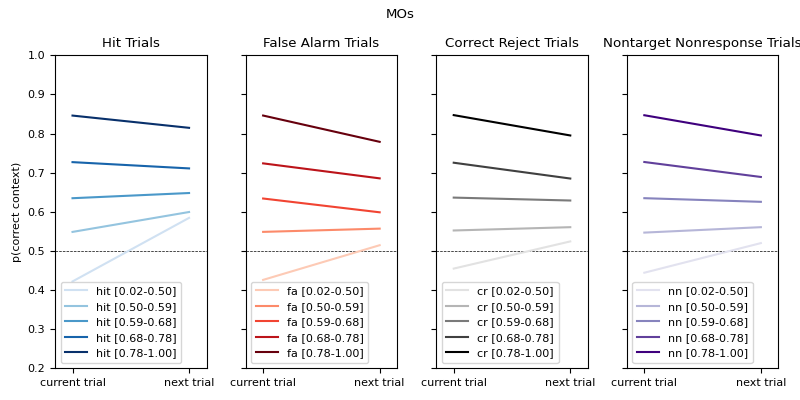

In [13]:
hit_colors=np.linspace(0.2,1.0,len(hit_baseline_bins)-1)
fa_colors=np.linspace(0.2,1.0,len(fa_baseline_bins)-1)#[::-1]
cr_colors=np.linspace(0.2,1.0,len(cr_baseline_bins)-1)
nn_colors=np.linspace(0.2,1.0,len(nontarget_nonresponse_baseline_bins)-1)#[::-1]

fig,ax=plt.subplots(1,4,figsize=(8,4),sharex=True,sharey=True)
ax[0].axhline(0.5,color='k',linewidth=0.5,linestyle='--')
ax[1].axhline(0.5,color='k',linewidth=0.5,linestyle='--')
ax[2].axhline(0.5,color='k',linewidth=0.5,linestyle='--')
ax[3].axhline(0.5,color='k',linewidth=0.5,linestyle='--')
# ax.axvline(0,color='k',linewidth=0.5,linestyle='--')

for bb in range(len(hit_baseline_bins)-1):
    bin_hits=hit_df.query(f'baseline_bin=={bb}')
    if bin_hits.shape[0]>0:
        ax[0].plot([0,1], [np.nanmedian(bin_hits['predict_proba']), np.nanmedian(bin_hits['predict_proba_next'])], 
                label=f'hit [{hit_baseline_bins[bb]:.2f}-{hit_baseline_bins[bb+1]:.2f}]', 
                color=plt.cm.Blues(hit_colors[bb]))


for bb in range(len(hit_baseline_bins)-1):
    bin_fas=fa_df.query(f'baseline_bin=={bb}')
    if bin_fas.shape[0]>0:
        ax[1].plot([0,1], [np.nanmedian(bin_fas['predict_proba']), np.nanmedian(bin_fas['predict_proba_next'])], 
                label=f'fa [{fa_baseline_bins[bb]:.2f}-{fa_baseline_bins[bb+1]:.2f}]', 
                color=plt.cm.Reds(fa_colors[bb]))

for bb in range(len(cr_baseline_bins)-1):
    bin_crs=cr_df.query(f'baseline_bin=={bb}')
    if bin_crs.shape[0]>0:
        ax[2].plot([0,1], [np.nanmedian(bin_crs['predict_proba']), np.nanmedian(bin_crs['predict_proba_next'])], 
                label=f'cr [{cr_baseline_bins[bb]:.2f}-{cr_baseline_bins[bb+1]:.2f}]', 
                color=plt.cm.Greys(cr_colors[bb]))
        
for bb in range(len(nontarget_nonresponse_baseline_bins)-1):
    bin_nns=nontarget_nonresponse_df.query(f'baseline_bin=={bb}')
    if bin_nns.shape[0]>0:
        ax[3].plot([0,1], [np.nanmedian(bin_nns['predict_proba']), np.nanmedian(bin_nns['predict_proba_next'])], 
                label=f'nn [{nontarget_nonresponse_baseline_bins[bb]:.2f}-{nontarget_nonresponse_baseline_bins[bb+1]:.2f}]', 
                color=plt.cm.Purples(nn_colors[bb]))


ax[0].set_xticks([0,1])
ax[0].set_xticklabels(['current trial', 'next trial'])
ax[0].set_xlim(-0.15,1.15)
ax[0].set_ylim(0.2,1.0)
ax[0].set_ylabel('p(correct context)')
ax[0].set_title('Hit Trials')
ax[0].legend()

ax[1].set_xticks([0,1])
ax[1].set_xticklabels(['current trial', 'next trial'])
ax[1].set_title('False Alarm Trials')
ax[1].legend()

ax[2].set_xticks([0,1])
ax[2].set_xticklabels(['current trial', 'next trial'])
ax[2].set_title('Correct Reject Trials')
ax[2].legend()

ax[3].set_xticks([0,1])
ax[3].set_xticklabels(['current trial', 'next trial'])
ax[3].set_title('Nontarget Nonresponse Trials')
ax[3].legend()

fig.suptitle(f"{sel_structure}")
fig.tight_layout()

In [14]:
# make dfs for other more specific trial types
vis_hit_df=pd.DataFrame({
    'predict_proba': vis_hit_predict_proba,
    'predict_proba_next': vis_hit_predict_proba_next,
    'session_id': all_trials_with_decoder_confidence.loc[vis_hit_mask,'session_id'].values,
    'block_index': all_trials_with_decoder_confidence.loc[vis_hit_mask,'block_index'].values,
})
if use_shared_bins:
    vis_hit_baseline_bins = shared_baseline_bins
else:
    vis_hit_baseline_bins=np.percentile(vis_hit_predict_proba[~np.isnan(vis_hit_predict_proba)],[0,20,40,60,80,100])
vis_hit_df['baseline_bin']=pd.cut(vis_hit_df['predict_proba'], bins=vis_hit_baseline_bins, labels=False, include_lowest=True)

aud_hit_df=pd.DataFrame({
    'predict_proba': aud_hit_predict_proba,
    'predict_proba_next': aud_hit_predict_proba_next,
    'session_id': all_trials_with_decoder_confidence.loc[aud_hit_mask,'session_id'].values,
    'block_index': all_trials_with_decoder_confidence.loc[aud_hit_mask,'block_index'].values,
})
if use_shared_bins:
    aud_hit_baseline_bins = shared_baseline_bins
else:
    aud_hit_baseline_bins=np.percentile(aud_hit_predict_proba[~np.isnan(aud_hit_predict_proba)],[0,20,40,60,80,100])
aud_hit_df['baseline_bin']=pd.cut(aud_hit_df['predict_proba'], bins=aud_hit_baseline_bins, labels=False, include_lowest=True)

vis_fa_df=pd.DataFrame({
    'predict_proba': vis_fa_predict_proba,
    'predict_proba_next': vis_fa_predict_proba_next,
    'session_id': all_trials_with_decoder_confidence.loc[vis_fa_mask,'session_id'].values,
    'block_index': all_trials_with_decoder_confidence.loc[vis_fa_mask,'block_index'].values,
})
if use_shared_bins:
    vis_fa_baseline_bins = shared_baseline_bins
else:
    vis_fa_baseline_bins=np.percentile(vis_fa_predict_proba[~np.isnan(vis_fa_predict_proba)],[0,20,40,60,80,100])
vis_fa_df['baseline_bin']=pd.cut(vis_fa_df['predict_proba'], bins=vis_fa_baseline_bins, labels=False, include_lowest=True)

aud_fa_df=pd.DataFrame({
    'predict_proba': aud_fa_predict_proba,
    'predict_proba_next': aud_fa_predict_proba_next,
    'session_id': all_trials_with_decoder_confidence.loc[aud_fa_mask,'session_id'].values,
    'block_index': all_trials_with_decoder_confidence.loc[aud_fa_mask,'block_index'].values,
})
if use_shared_bins:
    aud_fa_baseline_bins = shared_baseline_bins
else:
    aud_fa_baseline_bins=np.percentile(aud_fa_predict_proba[~np.isnan(aud_fa_predict_proba)],[0,20,40,60,80,100])
aud_fa_df['baseline_bin']=pd.cut(aud_fa_df['predict_proba'], bins=aud_fa_baseline_bins, labels=False, include_lowest=True)

vis_cr_df=pd.DataFrame({
    'predict_proba': vis_cr_predict_proba,
    'predict_proba_next': vis_cr_predict_proba_next,
    'session_id': all_trials_with_decoder_confidence.loc[vis_cr_mask,'session_id'].values,
    'block_index': all_trials_with_decoder_confidence.loc[vis_cr_mask,'block_index'].values,
})
if use_shared_bins:
    vis_cr_baseline_bins = shared_baseline_bins
else:
    vis_cr_baseline_bins=np.percentile(vis_cr_predict_proba[~np.isnan(vis_cr_predict_proba)],[0,20,40,60,80,100])
vis_cr_df['baseline_bin']=pd.cut(vis_cr_df['predict_proba'], bins=vis_cr_baseline_bins, labels=False, include_lowest=True)

aud_cr_df=pd.DataFrame({
    'predict_proba': aud_cr_predict_proba,
    'predict_proba_next': aud_cr_predict_proba_next,
    'session_id': all_trials_with_decoder_confidence.loc[aud_cr_mask,'session_id'].values,
    'block_index': all_trials_with_decoder_confidence.loc[aud_cr_mask,'block_index'].values,
})
if use_shared_bins:
    aud_cr_baseline_bins = shared_baseline_bins
else:
    aud_cr_baseline_bins=np.percentile(aud_cr_predict_proba[~np.isnan(aud_cr_predict_proba)],[0,20,40,60,80,100])
aud_cr_df['baseline_bin']=pd.cut(aud_cr_df['predict_proba'], bins=aud_cr_baseline_bins, labels=False, include_lowest=True)

vis_nontarget_nonresponse_df=pd.DataFrame({
    'predict_proba': vis_nontarget_nonresponse_predict_proba,
    'predict_proba_next': vis_nontarget_nonresponse_predict_proba_next,
    'session_id': all_trials_with_decoder_confidence.loc[vis_nontarget_nonresponse_mask,'session_id'].values,
    'block_index': all_trials_with_decoder_confidence.loc[vis_nontarget_nonresponse_mask,'block_index'].values,
})
if use_shared_bins:
    vis_nontarget_nonresponse_baseline_bins = shared_baseline_bins
else:
    vis_nontarget_nonresponse_baseline_bins=np.percentile(vis_nontarget_nonresponse_predict_proba[~np.isnan(vis_nontarget_nonresponse_predict_proba)],[0,20,40,60,80,100])
vis_nontarget_nonresponse_df['baseline_bin']=pd.cut(vis_nontarget_nonresponse_df['predict_proba'], bins=vis_nontarget_nonresponse_baseline_bins, labels=False, include_lowest=True)

aud_nontarget_nonresponse_df=pd.DataFrame({
    'predict_proba': aud_nontarget_nonresponse_predict_proba,
    'predict_proba_next': aud_nontarget_nonresponse_predict_proba_next,
    'session_id': all_trials_with_decoder_confidence.loc[aud_nontarget_nonresponse_mask,'session_id'].values,
    'block_index': all_trials_with_decoder_confidence.loc[aud_nontarget_nonresponse_mask,'block_index'].values,
})
if use_shared_bins:
    aud_nontarget_nonresponse_baseline_bins = shared_baseline_bins
else:
    aud_nontarget_nonresponse_baseline_bins=np.percentile(aud_nontarget_nonresponse_predict_proba[~np.isnan(aud_nontarget_nonresponse_predict_proba)],[0,20,40,60,80,100])
aud_nontarget_nonresponse_df['baseline_bin']=pd.cut(aud_nontarget_nonresponse_df['predict_proba'], bins=aud_nontarget_nonresponse_baseline_bins, labels=False, include_lowest=True)

vis_target_vis_block_response_df=pd.DataFrame({
    'predict_proba': vis_target_vis_block_response_predict_proba,
    'predict_proba_next': vis_target_vis_block_response_predict_proba_next,
    'session_id': all_trials_with_decoder_confidence.loc[vis_target_vis_block_response_mask,'session_id'].values,
    'block_index': all_trials_with_decoder_confidence.loc[vis_target_vis_block_response_mask,'block_index'].values,
})
if use_shared_bins:
    vis_target_vis_block_response_baseline_bins = shared_baseline_bins
else:
    vis_target_vis_block_response_baseline_bins=np.percentile(vis_target_vis_block_response_predict_proba[~np.isnan(vis_target_vis_block_response_predict_proba)],[0,20,40,60,80,100])
vis_target_vis_block_response_df['baseline_bin']=pd.cut(vis_target_vis_block_response_df['predict_proba'], bins=vis_target_vis_block_response_baseline_bins, labels=False, include_lowest=True)

vis_target_aud_block_response_df=pd.DataFrame({
    'predict_proba': vis_target_aud_block_response_predict_proba,
    'predict_proba_next': vis_target_aud_block_response_predict_proba_next,
    'session_id': all_trials_with_decoder_confidence.loc[vis_target_aud_block_response_mask,'session_id'].values,
    'block_index': all_trials_with_decoder_confidence.loc[vis_target_aud_block_response_mask,'block_index'].values,
})
if use_shared_bins:
    vis_target_aud_block_response_baseline_bins = shared_baseline_bins
else:
    vis_target_aud_block_response_baseline_bins=np.percentile(vis_target_aud_block_response_predict_proba[~np.isnan(vis_target_aud_block_response_predict_proba)],[0,20,40,60,80,100])
vis_target_aud_block_response_df['baseline_bin']=pd.cut(vis_target_aud_block_response_df['predict_proba'], bins=vis_target_aud_block_response_baseline_bins, labels=False, include_lowest=True)

aud_target_aud_block_response_df=pd.DataFrame({
    'predict_proba': aud_target_aud_block_response_predict_proba,
    'predict_proba_next': aud_target_aud_block_response_predict_proba_next,
    'session_id': all_trials_with_decoder_confidence.loc[aud_target_aud_block_response_mask,'session_id'].values,
    'block_index': all_trials_with_decoder_confidence.loc[aud_target_aud_block_response_mask,'block_index'].values,
})
if use_shared_bins:
    aud_target_aud_block_response_baseline_bins = shared_baseline_bins
else:
    aud_target_aud_block_response_baseline_bins=np.percentile(aud_target_aud_block_response_predict_proba[~np.isnan(aud_target_aud_block_response_predict_proba)],[0,20,40,60,80,100])
aud_target_aud_block_response_df['baseline_bin']=pd.cut(aud_target_aud_block_response_df['predict_proba'], bins=aud_target_aud_block_response_baseline_bins, labels=False, include_lowest=True)

aud_target_vis_block_response_df=pd.DataFrame({
    'predict_proba': aud_target_vis_block_response_predict_proba,
    'predict_proba_next': aud_target_vis_block_response_predict_proba_next,
    'session_id': all_trials_with_decoder_confidence.loc[aud_target_vis_block_response_mask,'session_id'].values,
    'block_index': all_trials_with_decoder_confidence.loc[aud_target_vis_block_response_mask,'block_index'].values,
})
if use_shared_bins:
    aud_target_vis_block_response_baseline_bins = shared_baseline_bins
else:
    aud_target_vis_block_response_baseline_bins=np.percentile(aud_target_vis_block_response_predict_proba[~np.isnan(aud_target_vis_block_response_predict_proba)],[0,20,40,60,80,100])
aud_target_vis_block_response_df['baseline_bin']=pd.cut(aud_target_vis_block_response_df['predict_proba'], bins=aud_target_vis_block_response_baseline_bins, labels=False, include_lowest=True)

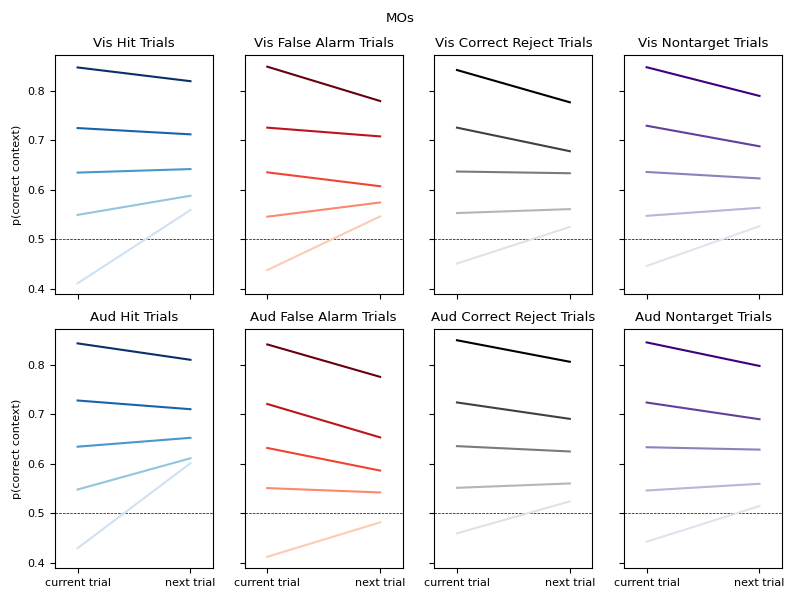

In [15]:
#plot these more specific trial types
fig,ax=plt.subplots(2,4,figsize=(8,6),sharex=True,sharey=True)
ax[0,0].axhline(0.5,color='k',linewidth=0.5,linestyle='--')
ax[0,1].axhline(0.5,color='k',linewidth=0.5,linestyle='--')
ax[0,2].axhline(0.5,color='k',linewidth=0.5,linestyle='--')
ax[0,3].axhline(0.5,color='k',linewidth=0.5,linestyle='--')
ax[1,0].axhline(0.5,color='k',linewidth=0.5,linestyle='--')
ax[1,1].axhline(0.5,color='k',linewidth=0.5,linestyle='--')
ax[1,2].axhline(0.5,color='k',linewidth=0.5,linestyle='--')
ax[1,3].axhline(0.5,color='k',linewidth=0.5,linestyle='--')
ax[0,0].set_title('Vis Hit Trials')
ax[0,1].set_title('Vis False Alarm Trials')
ax[0,2].set_title('Vis Correct Reject Trials')
ax[0,3].set_title('Vis Nontarget Trials')
ax[1,0].set_title('Aud Hit Trials')
ax[1,1].set_title('Aud False Alarm Trials')
ax[1,2].set_title('Aud Correct Reject Trials')
ax[1,3].set_title('Aud Nontarget Trials')
ax[0,0].set_ylabel('p(correct context)')
ax[1,0].set_ylabel('p(correct context)')
ax[1,0].set_xticks([0,1])
ax[1,0].set_xticklabels(['current trial', 'next trial'])
ax[1,0].set_xlim(-0.2,1.2)

for bb in range(len(vis_hit_baseline_bins)-1):
    bin_vis_hits=vis_hit_df.query(f'baseline_bin=={bb}')
    if bin_vis_hits.shape[0]>0:
        ax[0,0].plot([0,1], [np.nanmedian(bin_vis_hits['predict_proba']), np.nanmedian(bin_vis_hits['predict_proba_next'])], 
                label=f'vis hit [{vis_hit_baseline_bins[bb]:.2f}-{vis_hit_baseline_bins[bb+1]:.2f}]', 
                color=plt.cm.Blues(hit_colors[bb]))
for bb in range(len(aud_hit_baseline_bins)-1):
    bin_aud_hits=aud_hit_df.query(f'baseline_bin=={bb}')
    if bin_aud_hits.shape[0]>0:
        ax[1,0].plot([0,1], [np.nanmedian(bin_aud_hits['predict_proba']), np.nanmedian(bin_aud_hits['predict_proba_next'])], 
                label=f'aud hit [{aud_hit_baseline_bins[bb]:.2f}-{aud_hit_baseline_bins[bb+1]:.2f}]', 
                color=plt.cm.Blues(hit_colors[bb]))
for bb in range(len(vis_fa_baseline_bins)-1):
    bin_vis_fas=vis_fa_df.query(f'baseline_bin=={bb}')
    if bin_vis_fas.shape[0]>0:
        ax[0,1].plot([0,1], [np.nanmedian(bin_vis_fas['predict_proba']), np.nanmedian(bin_vis_fas['predict_proba_next'])], 
                label=f'vis fa [{vis_fa_baseline_bins[bb]:.2f}-{vis_fa_baseline_bins[bb+1]:.2f}]', 
                color=plt.cm.Reds(fa_colors[bb]))
for bb in range(len(aud_fa_baseline_bins)-1):
    bin_aud_fas=aud_fa_df.query(f'baseline_bin=={bb}')
    if bin_aud_fas.shape[0]>0:
        ax[1,1].plot([0,1], [np.nanmedian(bin_aud_fas['predict_proba']), np.nanmedian(bin_aud_fas['predict_proba_next'])], 
                label=f'aud fa [{aud_fa_baseline_bins[bb]:.2f}-{aud_fa_baseline_bins[bb+1]:.2f}]', 
                color=plt.cm.Reds(fa_colors[bb]))
for bb in range(len(vis_cr_baseline_bins)-1):
    bin_vis_crs=vis_cr_df.query(f'baseline_bin=={bb}')
    if bin_vis_crs.shape[0]>0:
        ax[0,2].plot([0,1], [np.nanmedian(bin_vis_crs['predict_proba']), np.nanmedian(bin_vis_crs['predict_proba_next'])], 
                label=f'vis cr [{vis_cr_baseline_bins[bb]:.2f}-{vis_cr_baseline_bins[bb+1]:.2f}]', 
                color=plt.cm.Greys(cr_colors[bb]))
for bb in range(len(aud_cr_baseline_bins)-1):
    bin_aud_crs=aud_cr_df.query(f'baseline_bin=={bb}')
    if bin_aud_crs.shape[0]>0:
        ax[1,2].plot([0,1], [np.nanmedian(bin_aud_crs['predict_proba']), np.nanmedian(bin_aud_crs['predict_proba_next'])], 
                label=f'aud cr [{aud_cr_baseline_bins[bb]:.2f}-{aud_cr_baseline_bins[bb+1]:.2f}]', 
                color=plt.cm.Greys(cr_colors[bb]))
for bb in range(len(vis_nontarget_nonresponse_baseline_bins)-1):
    bin_vis_nns=vis_nontarget_nonresponse_df.query(f'baseline_bin=={bb}')
    if bin_vis_nns.shape[0]>0:
        ax[0,3].plot([0,1], [np.nanmedian(bin_vis_nns['predict_proba']), np.nanmedian(bin_vis_nns['predict_proba_next'])], 
                label=f'vis nontarget nonresponse [{vis_nontarget_nonresponse_baseline_bins[bb]:.2f}-{vis_nontarget_nonresponse_baseline_bins[bb+1]:.2f}]', 
                color=plt.cm.Purples(nn_colors[bb]))
for bb in range(len(aud_nontarget_nonresponse_baseline_bins)-1):
    bin_aud_nns=aud_nontarget_nonresponse_df.query(f'baseline_bin=={bb}')
    if bin_aud_nns.shape[0]>0:
        ax[1,3].plot([0,1], [np.nanmedian(bin_aud_nns['predict_proba']), np.nanmedian(bin_aud_nns['predict_proba_next'])], 
                label=f'aud nontarget nonresponse [{aud_nontarget_nonresponse_baseline_bins[bb]:.2f}-{aud_nontarget_nonresponse_baseline_bins[bb+1]:.2f}]', 
                color=plt.cm.Purples(nn_colors[bb]))

fig.suptitle(f"{sel_structure}")
fig.tight_layout()

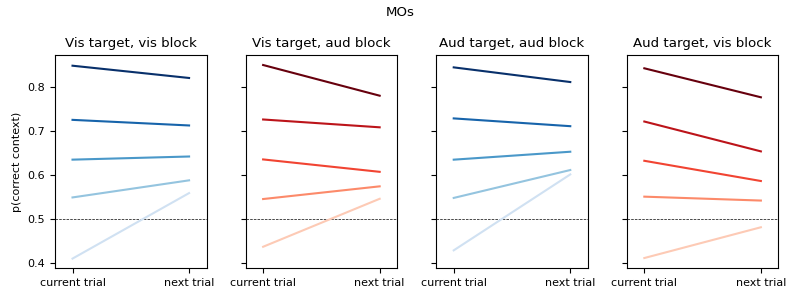

In [16]:
#plot block specific changes

fig,ax=plt.subplots(1,4,figsize=(8,3),sharex=True,sharey=True)
ax[0].axhline(0.5,color='k',linewidth=0.5,linestyle='--')
ax[1].axhline(0.5,color='k',linewidth=0.5,linestyle='--')
ax[2].axhline(0.5,color='k',linewidth=0.5,linestyle='--')
ax[3].axhline(0.5,color='k',linewidth=0.5,linestyle='--')

ax[0].set_title('Vis target, vis block')
ax[1].set_title('Vis target, aud block')
ax[2].set_title('Aud target, aud block')
ax[3].set_title('Aud target, vis block')

for bb in range(len(vis_target_vis_block_response_baseline_bins)-1):
    bin_vis_target_vis_block=vis_target_vis_block_response_df.query(f'baseline_bin=={bb}')
    if bin_vis_target_vis_block.shape[0]>0:
        ax[0].plot([0,1], [np.nanmedian(bin_vis_target_vis_block['predict_proba']), np.nanmedian(bin_vis_target_vis_block['predict_proba_next'])], 
                label=f'vis target vis block [{vis_target_vis_block_response_baseline_bins[bb]:.2f}-{vis_target_vis_block_response_baseline_bins[bb+1]:.2f}]', 
                color=plt.cm.Blues(hit_colors[bb]))
for bb in range(len(vis_target_aud_block_response_baseline_bins)-1):
    bin_vis_target_aud_block=vis_target_aud_block_response_df.query(f'baseline_bin=={bb}')
    if bin_vis_target_aud_block.shape[0]>0:
        ax[1].plot([0,1], [np.nanmedian(bin_vis_target_aud_block['predict_proba']), np.nanmedian(bin_vis_target_aud_block['predict_proba_next'])], 
                label=f'vis target aud block [{vis_target_aud_block_response_baseline_bins[bb]:.2f}-{vis_target_aud_block_response_baseline_bins[bb+1]:.2f}]', 
                color=plt.cm.Reds(hit_colors[bb]))
for bb in range(len(aud_target_aud_block_response_baseline_bins)-1):
    bin_aud_target_aud_block=aud_target_aud_block_response_df.query(f'baseline_bin=={bb}')
    if bin_aud_target_aud_block.shape[0]>0:
        ax[2].plot([0,1], [np.nanmedian(bin_aud_target_aud_block['predict_proba']), np.nanmedian(bin_aud_target_aud_block['predict_proba_next'])], 
                label=f'aud target aud block [{aud_target_aud_block_response_baseline_bins[bb]:.2f}-{aud_target_aud_block_response_baseline_bins[bb+1]:.2f}]', 
                color=plt.cm.Blues(hit_colors[bb]))
for bb in range(len(aud_target_vis_block_response_baseline_bins)-1):
    bin_aud_target_vis_block=aud_target_vis_block_response_df.query(f'baseline_bin=={bb}')
    if bin_aud_target_vis_block.shape[0]>0:
        ax[3].plot([0,1], [np.nanmedian(bin_aud_target_vis_block['predict_proba']), np.nanmedian(bin_aud_target_vis_block['predict_proba_next'])], 
                label=f'aud target vis block [{aud_target_vis_block_response_baseline_bins[bb]:.2f}-{aud_target_vis_block_response_baseline_bins[bb+1]:.2f}]', 
                color=plt.cm.Reds(hit_colors[bb]))
        
ax[0].set_xticks([0,1])
ax[0].set_xticklabels(['current trial', 'next trial'])
ax[0].set_xlim(-0.15,1.15)
# ax[0].set_ylim(0.2,1.0)
ax[0].set_ylabel('p(correct context)')

fig.suptitle(f"{sel_structure}")
fig.tight_layout()

In [10]:
# np.sum(~np.isnan(adj_structure_predict_proba))